# Laboratorio 5 - Clasificación multiclase de imágenes con regresión logística (One-vs-All) y Extracción de Características HOG

Este cuadernillo entrena un clasificador de regresión logística one-vs-all para reconocer 100 clases de imágenes de 32x32 RGB (dataset CIFAR-100), organizadas en subcarpetas por clase dentro de `train/` y `test/`.

### Mejoras aplicadas para reducir ruido y mejorar la precisión:
1. **Extracción de características HOG (Histogram of Oriented Gradients)**: En lugar de usar los píxeles crudos (3072 valores), se extraen descriptores HOG (1568 valores) que capturan bordes, formas y gradientes locales. Esto permite que el modelo ignore el ruido de fondo e iluminación variada.
2. **Baja regularización (`lambda_ = 0.1`)**: Al usar características HOG más discriminativas, una menor regularización le da suficiente libertad al clasificador lineal para encontrar fronteras de separación óptimas.
3. **Evaluación completa de las 100 clases**: Se muestra el rendimiento y gráficos de precisión para las 100 clases del dataset.

In [1]:
# Esta celda importa librerías para manejo de datos, imágenes, álgebra, gráficos y extracción de características HOG.
# Sirve para preparar el entorno antes del entrenamiento del modelo.
import os
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib import pyplot
from scipy import optimize
from skimage.feature import hog
%matplotlib inline

## 1. Carga del dataset

Las imágenes están organizadas en subcarpetas por clase dentro de las carpetas `train` y `test`. En vez de usar la división train/test que ya trae el dataset, se combinan todas las imágenes de ambas carpetas en un único conjunto, para luego aplicar nuestra propia división aleatoria de 80/20. Esto nos da control total sobre la proporción y asegura que la partición sea reproducible (semilla fija).

In [2]:
# Esta celda define las rutas de las carpetas train y test del dataset.
# Sirve para tener un solo lugar donde ajustar la ubicación real de las imágenes.
train_dir = 'train'  # ajusta a tu ruta real
test_dir = 'test'    # ajusta a tu ruta real

carpetas_clase = sorted(os.listdir(train_dir))
print(f'Clases encontradas: {carpetas_clase}')

Clases encontradas: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'wh

In [3]:
# Esta celda recorre train/ y test/ (todas las subcarpetas de clase) y arma un DataFrame con pandas.
# Sirve para combinar TODAS las imágenes en un solo pool, ya que el split 80/20 lo haremos nosotros mismos.
columnas_pixeles = [f'p{i}' for i in range(32 * 32 * 3)]

filas = []
for carpeta_base in [train_dir, test_dir]:
    for nombre_clase in carpetas_clase:
        ruta_clase = os.path.join(carpeta_base, nombre_clase)
        for archivo in os.listdir(ruta_clase):
            img = Image.open(os.path.join(ruta_clase, archivo)).convert('RGB')
            filas.append(list(np.array(img).flatten()) + [nombre_clase])

df = pd.DataFrame(filas, columns=columnas_pixeles + ['clase'])

print(f'Dimensiones del DataFrame combinado (train+test): {df.shape}')
print(df['clase'].value_counts())

Dimensiones del DataFrame combinado (train+test): (60000, 3073)
clase
apple            600
aquarium_fish    600
baby             600
bear             600
beaver           600
                ... 
whale            600
willow_tree      600
wolf             600
woman            600
worm             600
Name: count, Length: 100, dtype: int64


## 2. Codificación de la clase y diagnóstico de los datos

Al igual que en los laboratorios anteriores, la columna de texto (`clase`) se convierte a un valor numérico con `pd.factorize`, guardando el mapeo para poder mostrar los nombres reales de las clases más adelante. También se verifica que no existan valores nulos y que el tipo de dato sea el esperado antes de continuar.

In [4]:
# Esta celda convierte la columna de texto 'clase' a un número entero.
# Sirve para poder usarla dentro de las operaciones matemáticas del modelo.
df['clase'], categorias = pd.factorize(df['clase'])
clases = list(categorias)
print(f'Clases codificadas: {dict(enumerate(clases))}')

y = df['clase'].values
X = df.drop(columns=['clase']).values.astype(float)

m, n = X.shape
num_labels = len(clases)

print(f'Dimensiones finales: {m} ejemplos, {n} propiedades (píxeles)')
print(f'Tipo de datos de X: {X.dtype}')
print(f'Total de datos nulos (NaN): {np.isnan(X).sum()}')

Clases codificadas: {0: 'apple', 1: 'aquarium_fish', 2: 'baby', 3: 'bear', 4: 'beaver', 5: 'bed', 6: 'bee', 7: 'beetle', 8: 'bicycle', 9: 'bottle', 10: 'bowl', 11: 'boy', 12: 'bridge', 13: 'bus', 14: 'butterfly', 15: 'camel', 16: 'can', 17: 'castle', 18: 'caterpillar', 19: 'cattle', 20: 'chair', 21: 'chimpanzee', 22: 'clock', 23: 'cloud', 24: 'cockroach', 25: 'couch', 26: 'crab', 27: 'crocodile', 28: 'cup', 29: 'dinosaur', 30: 'dolphin', 31: 'elephant', 32: 'flatfish', 33: 'forest', 34: 'fox', 35: 'girl', 36: 'hamster', 37: 'house', 38: 'kangaroo', 39: 'keyboard', 40: 'lamp', 41: 'lawn_mower', 42: 'leopard', 43: 'lion', 44: 'lizard', 45: 'lobster', 46: 'man', 47: 'maple_tree', 48: 'motorcycle', 49: 'mountain', 50: 'mouse', 51: 'mushroom', 52: 'oak_tree', 53: 'orange', 54: 'orchid', 55: 'otter', 56: 'palm_tree', 57: 'pear', 58: 'pickup_truck', 59: 'pine_tree', 60: 'plain', 61: 'plate', 62: 'poppy', 63: 'porcupine', 64: 'possum', 65: 'rabbit', 66: 'raccoon', 67: 'ray', 68: 'road', 69: 'r

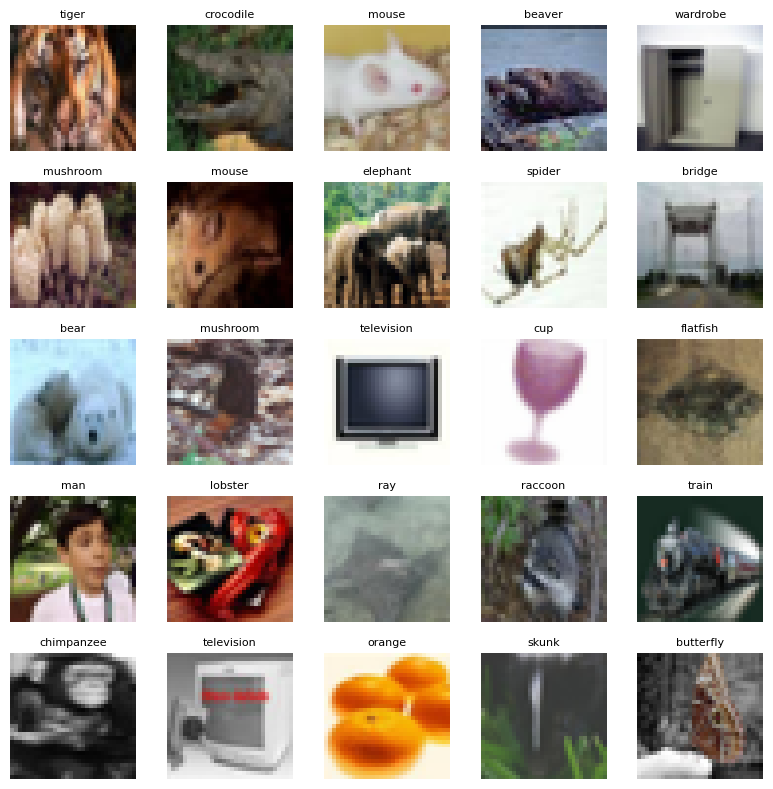

In [5]:
# Esta celda muestra una cuadrícula de imágenes aleatorias del dataset combinado.
# Sirve para verificar visualmente que la carga de datos fue correcta.
n_muestra_vis = min(25, m)
rand_indices = np.random.choice(m, n_muestra_vis, replace=False)
lado = int(np.ceil(np.sqrt(n_muestra_vis)))

fig, axes = pyplot.subplots(lado, lado, figsize=(8, 8))
for ax, idx in zip(np.array(axes).ravel(), rand_indices):
    imagen = X[idx].reshape(32, 32, 3).astype(np.uint8)
    ax.imshow(imagen)
    ax.set_title(clases[y[idx]], fontsize=8)
    ax.axis('off')
pyplot.tight_layout()
pyplot.show()

## 3. División 80% entrenamiento / 20% prueba

Se mezclan los índices de todo el conjunto (semilla fija para que el resultado sea reproducible) y se separa un 80% para entrenar y un 20% para evaluar. Las imágenes de prueba quedan completamente aparte y no participan en ningún paso del entrenamiento, solo se usan al final para medir qué tan bien generaliza el modelo.

In [6]:
# Esta celda divide el dataset combinado en 80% entrenamiento y 20% prueba.
# Sirve para validar el modelo con datos que nunca participaron en el entrenamiento.
np.random.seed(42)
indices = np.random.permutation(m)
corte = int(0.8 * m)
idx_train, idx_test = indices[:corte], indices[corte:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f'Entrenamiento: {X_train.shape[0]} ejemplos | Prueba: {X_test.shape[0]} ejemplos')

Entrenamiento: 48000 ejemplos | Prueba: 12000 ejemplos


## 4. Extracción de características HOG y Normalización

Para solucionar el problema del ruido en los fondos e iluminación variable de las imágenes, extraemos descriptores **HOG (Histogram of Oriented Gradients)** de cada imagen de 32x32x3. Luego, normalizamos las características (media 0 y desviación estándar 1) calculando los parámetros únicamente en el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

In [7]:
# Esta celda extrae características HOG (Histogram of Oriented Gradients) y las normaliza.
# HOG captura la estructura de bordes e ignora el ruido de fondo de las imágenes.
def extraer_hog_dataset(X_flat, img_size=32):
    features = []
    for img_flat in X_flat:
        img = img_flat.reshape(img_size, img_size, 3).astype(np.uint8)
        feat = hog(img,
                   orientations=8,
                   pixels_per_cell=(4, 4),
                   cells_per_block=(2, 2),
                   channel_axis=-1)
        features.append(feat)
    return np.array(features)

print('Extraendo características HOG del conjunto de entrenamiento y prueba...')
X_train_hog = extraer_hog_dataset(X_train)
X_test_hog = extraer_hog_dataset(X_test)
print(f'Dimensiones de X_train HOG: {X_train_hog.shape}')
print(f'Dimensiones de X_test HOG: {X_test_hog.shape}')

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evita división por cero en características constantes
    return (X - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train_hog)
X_test_norm = (X_test_hog - mu) / sigma

print(f'X_train_norm -> media: {X_train_norm.mean():.4f}, desviación: {X_train_norm.std():.4f}')

Extraendo características HOG del conjunto de entrenamiento y prueba...
Dimensiones de X_train HOG: (48000, 1568)
Dimensiones de X_test HOG: (12000, 1568)
X_train_norm -> media: 0.0000, desviación: 1.0000


## 5. Función sigmoide y costo de regresión logística regularizada (con ponderación de clase)

Se reutiliza la misma función sigmoide del cuadernillo de clase (`reg_log_onevsall`). La función de costo se amplía con un parámetro `peso_positivo`: en un esquema one-vs-all con 100 clases, cada clasificador binario ve solo ~1% de ejemplos positivos (su clase) contra ~99% negativos (todas las demás). Sin corregir ese desbalance, el optimizador puede lograr un costo bajo simplemente prediciendo "no" casi siempre, sin aprender realmente a reconocer la clase — por eso se pondera la clase positiva para que el error de ignorarla pese más.

In [8]:
# Esta celda define la función sigmoide.
# Sirve para convertir cualquier valor real en una probabilidad entre 0 y 1.
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [9]:
# Esta celda calcula el costo y el gradiente de la regresión logística regularizada,
# ponderando la clase positiva para compensar el desbalance ~99 a 1 de cada clasificador one-vs-all.
def lrCostFunction(theta, X, y, lambda_, peso_positivo=1.0):
    m = y.size
    h = sigmoid(X.dot(theta))

    temp = theta.copy()
    temp[0] = 0  # no se regulariza el término de sesgo (theta_0)

    eps = 1e-12  # evita log(0) por estabilidad numérica
    pesos = np.where(y == 1, peso_positivo, 1.0)
    J = (1 / m) * np.sum(pesos * (-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps))) + (lambda_ / (2 * m)) * np.sum(temp ** 2)
    grad = (1 / m) * ((h - y) * pesos).dot(X) + (lambda_ / m) * temp

    return J, grad

## 6. Entrenamiento One-vs-All

Se entrena un clasificador de regresión logística por cada una de las 100 clases (`optimize.minimize` con método `CG`). Se ajusta `lambda_ = 0.1` (regularización baja) para dar libertad al modelo al separar el espacio de características HOG y se mantiene la ponderación automática de la clase positiva para manejar el desbalance One-vs-All.

In [10]:
# Esta celda entrena un clasificador de regresión logística por cada clase.
# Sirve para obtener una matriz all_theta con los parámetros de cada clasificador,
# además de un historial de costo por clase (gracias al callback) para graficar la convergencia.
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    historiales_costo = []

    for c in range(num_labels):
        theta_inicial = np.zeros(n + 1)
        y_clase = (y == c).astype(float)  # 1 si pertenece a la clase c, 0 si no

        n_pos = np.sum(y_clase)
        n_neg = y_clase.size - n_pos
        peso_positivo = n_neg / n_pos  # balancea el desbalance real de esta clase

        historial = []
        def callback(theta_actual, X=X, y_clase=y_clase, peso_positivo=peso_positivo):
            J, _ = lrCostFunction(theta_actual, X, y_clase, lambda_, peso_positivo)
            historial.append(J)

        resultado = optimize.minimize(lrCostFunction,
                                       theta_inicial,
                                       args=(X, y_clase, lambda_, peso_positivo),
                                       jac=True,
                                       method='CG',
                                       options={'maxiter': 800},
                                       callback=callback)
        all_theta[c] = resultado.x
        historiales_costo.append(historial)
        print(f"Clase '{clases[c]}' entrenada, costo final: {resultado.fun:.6f}")

    return all_theta, historiales_costo

lambda_ = 0.1
all_theta, historiales_costo = oneVsAll(X_train_norm, y_train, num_labels, lambda_)
print(f'\nForma de all_theta: {all_theta.shape}')

Clase 'apple' entrenada, costo final: 0.069704
Clase 'aquarium_fish' entrenada, costo final: 0.145894
Clase 'baby' entrenada, costo final: 0.329763
Clase 'bear' entrenada, costo final: 0.298543
Clase 'beaver' entrenada, costo final: 0.266783
Clase 'bed' entrenada, costo final: 0.062364
Clase 'bee' entrenada, costo final: 0.176552
Clase 'beetle' entrenada, costo final: 0.208932
Clase 'bicycle' entrenada, costo final: 0.030955
Clase 'bottle' entrenada, costo final: 0.020827
Clase 'bowl' entrenada, costo final: 0.089882
Clase 'boy' entrenada, costo final: 0.228311
Clase 'bridge' entrenada, costo final: 0.174612
Clase 'bus' entrenada, costo final: 0.091899
Clase 'butterfly' entrenada, costo final: 0.201509
Clase 'camel' entrenada, costo final: 0.255723
Clase 'can' entrenada, costo final: 0.104800
Clase 'castle' entrenada, costo final: 0.104127
Clase 'caterpillar' entrenada, costo final: 0.288581
Clase 'cattle' entrenada, costo final: 0.193406
Clase 'chair' entrenada, costo final: 0.002332


## 7. Gráfico de costo

Se grafica la evolución del costo durante el entrenamiento de cada clasificador (uno por clase). Todas las curvas deberían decrecer y estabilizarse, lo que indica que cada clasificador efectivamente está aprendiendo a separar su clase del resto.

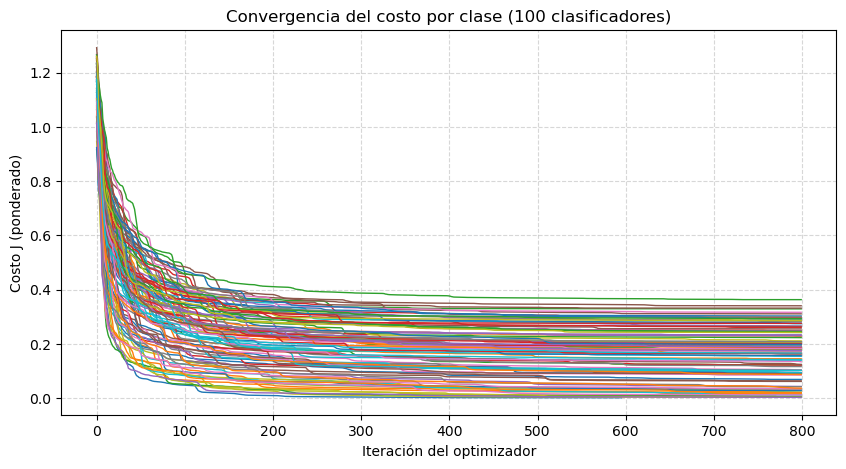

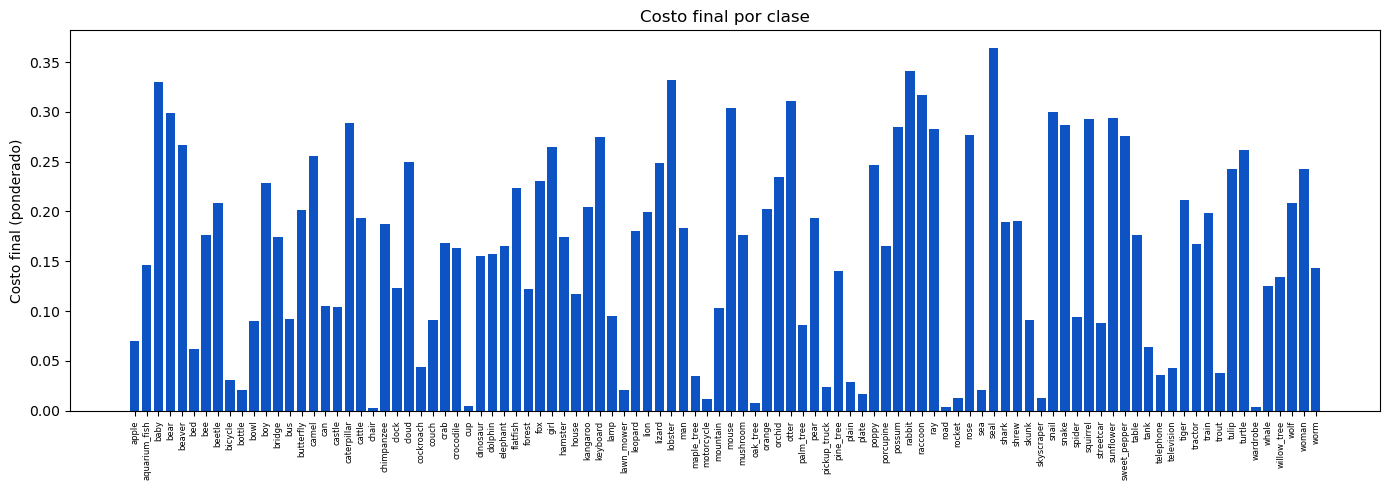

In [11]:
# Esta celda grafica la convergencia del costo de cada clasificador (una curva por clase).
# Sirve para verificar visualmente que el entrenamiento efectivamente redujo el costo.
pyplot.figure(figsize=(10, 5))
for c, historial in enumerate(historiales_costo):
    pyplot.plot(historial, lw=1)
pyplot.xlabel('Iteración del optimizador')
pyplot.ylabel('Costo J (ponderado)')
pyplot.title('Convergencia del costo por clase (100 clasificadores)')
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.show()

# Costo final por clase, más legible que 100 curvas superpuestas
costos_finales = [h[-1] if h else None for h in historiales_costo]
pyplot.figure(figsize=(14, 5))
pyplot.bar(clases, costos_finales, color='#0d53c4')
pyplot.xticks(rotation=90, fontsize=6)
pyplot.ylabel('Costo final (ponderado)')
pyplot.title('Costo final por clase')
pyplot.tight_layout()
pyplot.show()

## 8. Predicción One-vs-All

Con los parámetros ya entrenados, se calcula la probabilidad de pertenencia a cada clase para cada ejemplo, y se elige la clase con mayor probabilidad como predicción final.

In [12]:
# Esta celda predice la clase de cada ejemplo usando los clasificadores entrenados.
# Sirve para convertir las probabilidades de cada clase en una única etiqueta predicha.
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    probabilidades = sigmoid(X.dot(all_theta.T))
    return np.argmax(probabilidades, axis=1)

## 9. Validación del modelo

Se mide la precisión tanto en el conjunto de entrenamiento (para verificar que el modelo efectivamente aprendió) como en el conjunto de prueba (para verificar qué tan bien generaliza a imágenes que nunca vio, ya que estas fueron completamente separadas antes de entrenar).

In [13]:
# Esta celda mide la precisión del modelo en entrenamiento y en prueba.
# Sirve para comparar qué tan bien generaliza el modelo a datos nuevos.
pred_train = predictOneVsAll(all_theta, X_train_norm)
precision_train = np.mean(pred_train == y_train) * 100

pred_test = predictOneVsAll(all_theta, X_test_norm)
precision_test = np.mean(pred_test == y_test) * 100

print(f'Precisión en entrenamiento: {precision_train:.2f}%')
print(f'Precisión en prueba: {precision_test:.2f}%')

print('\nAlgunas predicciones de ejemplo (conjunto de prueba):')
for i in range(min(15, len(y_test))):
    marca = '✓' if y_test[i] == pred_test[i] else '✗'
    print(f'Real: {clases[y_test[i]]:15s} | Predicho: {clases[pred_test[i]]:15s} {marca}')

Precisión en entrenamiento: 46.30%
Precisión en prueba: 12.93%

Algunas predicciones de ejemplo (conjunto de prueba):
Real: snail           | Predicho: boy             ✗
Real: tank            | Predicho: raccoon         ✗
Real: beaver          | Predicho: skunk           ✗
Real: bear            | Predicho: bear            ✓
Real: crab            | Predicho: bowl            ✗
Real: crocodile       | Predicho: crocodile       ✓
Real: mouse           | Predicho: woman           ✗
Real: kangaroo        | Predicho: dolphin         ✗
Real: willow_tree     | Predicho: boy             ✗
Real: camel           | Predicho: sunflower       ✗
Real: beaver          | Predicho: bicycle         ✗
Real: plain           | Predicho: mountain        ✗
Real: poppy           | Predicho: raccoon         ✗
Real: seal            | Predicho: sea             ✗
Real: skyscraper      | Predicho: caterpillar     ✗


## 10. Gráfico y reporte de precisión para las 100 clases

Se compara la precisión general en entrenamiento contra la de prueba, y se calcula y grafica la precisión individual para **las 100 clases del dataset**, mostrando además una tabla detallada de todas las clases ordenadas por su rendimiento.

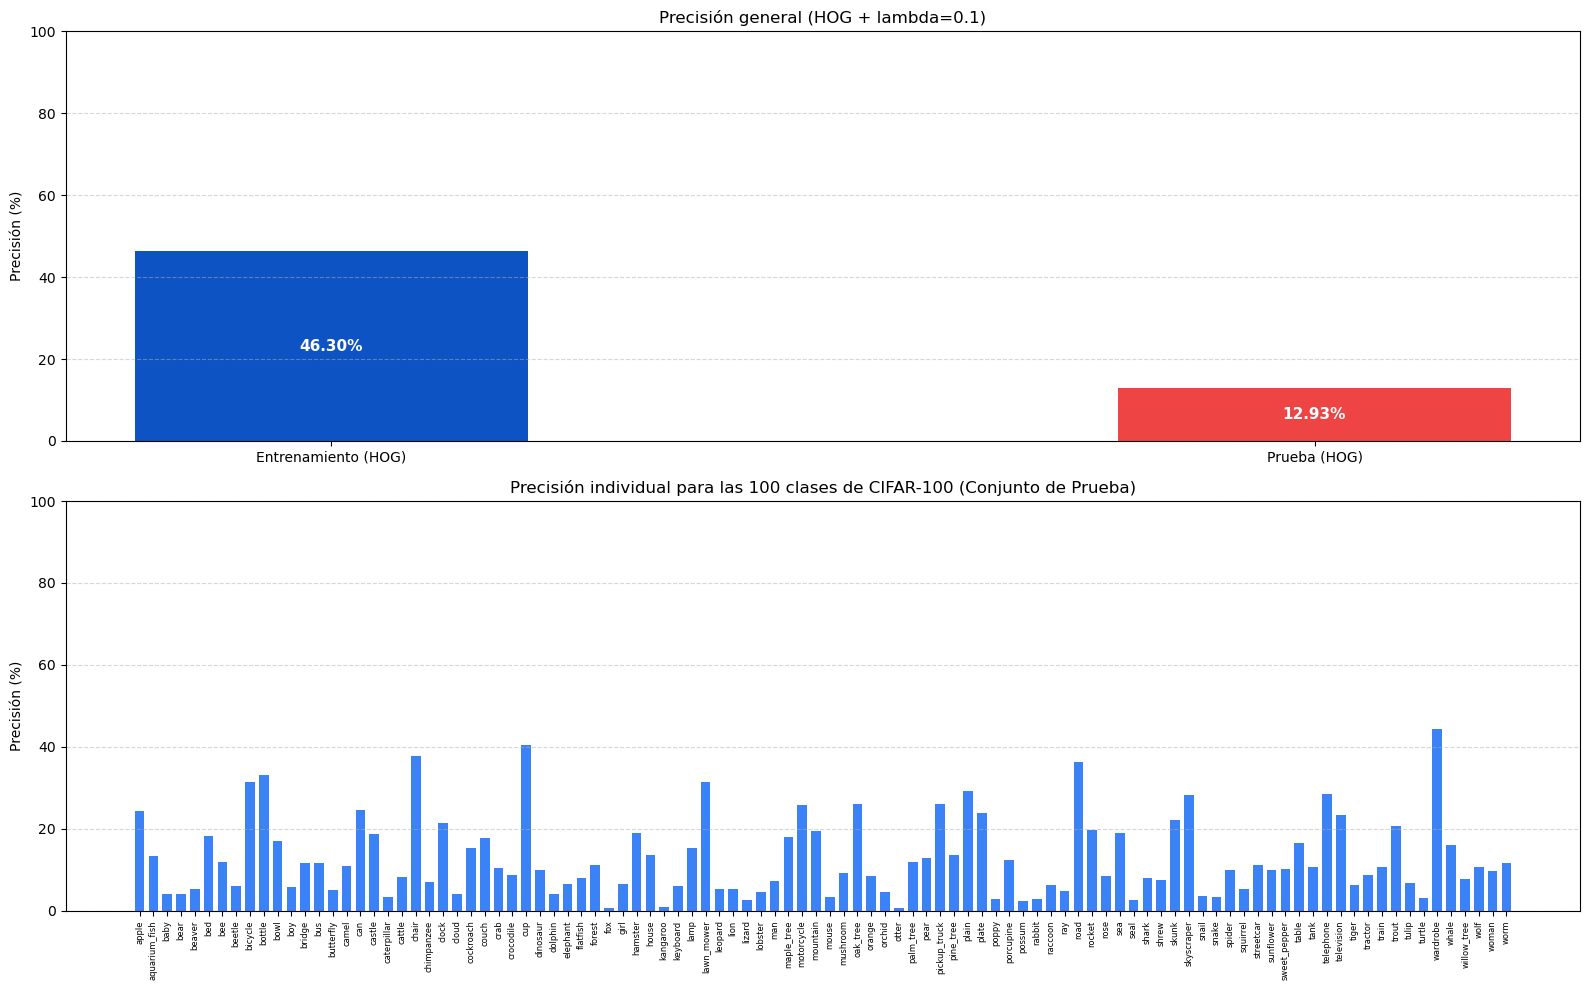


--- REPORTE DETALLADO DE LAS 100 CLASES (Ordenadas de mayor a menor precisión) ---
 ID         Clase  Precisión_Test (%)
 94      wardrobe               44.44
 28           cup               40.32
 20         chair               37.84
 68          road               36.36
  9        bottle               33.10
  8       bicycle               31.43
 41    lawn_mower               31.39
 60         plain               29.13
 86     telephone               28.57
 76    skyscraper               28.35
 58  pickup_truck               26.09
 52      oak_tree               26.05
 48    motorcycle               25.81
 16           can               24.58
  0         apple               24.39
 61         plate               23.85
 87    television               23.47
 75         skunk               22.22
 22         clock               21.37
 91         trout               20.69
 69        rocket               19.69
 49      mountain               19.42
 36       hamster               19.01
 71 

In [14]:
# Esta celda grafica la precisión general (train vs test) y la precisión por clase en el conjunto de prueba para las 100 clases.
fig, axes = pyplot.subplots(2, 1, figsize=(16, 10))

axes[0].bar(['Entrenamiento (HOG)', 'Prueba (HOG)'], [precision_train, precision_test], color=['#0d53c4', '#ef4444'], width=0.4)
axes[0].set_ylabel('Precisión (%)')
axes[0].set_ylim(0, 100)
axes[0].set_title(f'Precisión general (HOG + lambda={lambda_})')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
for p, val in zip(axes[0].patches, [precision_train, precision_test]):
    axes[0].annotate(f'{val:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                     ha='center', va='center', fontsize=11, color='white', weight='bold')

precision_por_clase = []
for c in range(num_labels):
    mask = y_test == c
    prec = np.mean(pred_test[mask] == y_test[mask]) * 100 if mask.sum() > 0 else 0
    precision_por_clase.append(prec)

precision_por_clase = np.array(precision_por_clase)
x_indices = np.arange(num_labels)

axes[1].bar(x_indices, precision_por_clase, color='#3b82f6', width=0.7)
axes[1].set_xticks(x_indices)
axes[1].set_xticklabels(clases, rotation=90, fontsize=6)
axes[1].set_ylabel('Precisión (%)')
axes[1].set_ylim(0, 100)
axes[1].set_title('Precisión individual para las 100 clases de CIFAR-100 (Conjunto de Prueba)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

pyplot.tight_layout()
pyplot.show()

# Imprimir reporte ordenado de las 100 clases
df_clases_reporte = pd.DataFrame({
    'ID': range(num_labels),
    'Clase': clases,
    'Precisión_Test (%)': np.round(precision_por_clase, 2)
}).sort_values(by='Precisión_Test (%)', ascending=False)

print(f'\n--- REPORTE DETALLADO DE LAS {num_labels} CLASES (Ordenadas de mayor a menor precisión) ---')
print(df_clases_reporte.to_string(index=False))


## 11. Matriz de confusión

Muestra cuántas veces se predijo cada clase frente a la clase real. Con 100 clases el mapa de calor completo es difícil de leer en detalle, así que además se listan los pares de clases que más se confunden entre sí — normalmente clases visualmente parecidas.

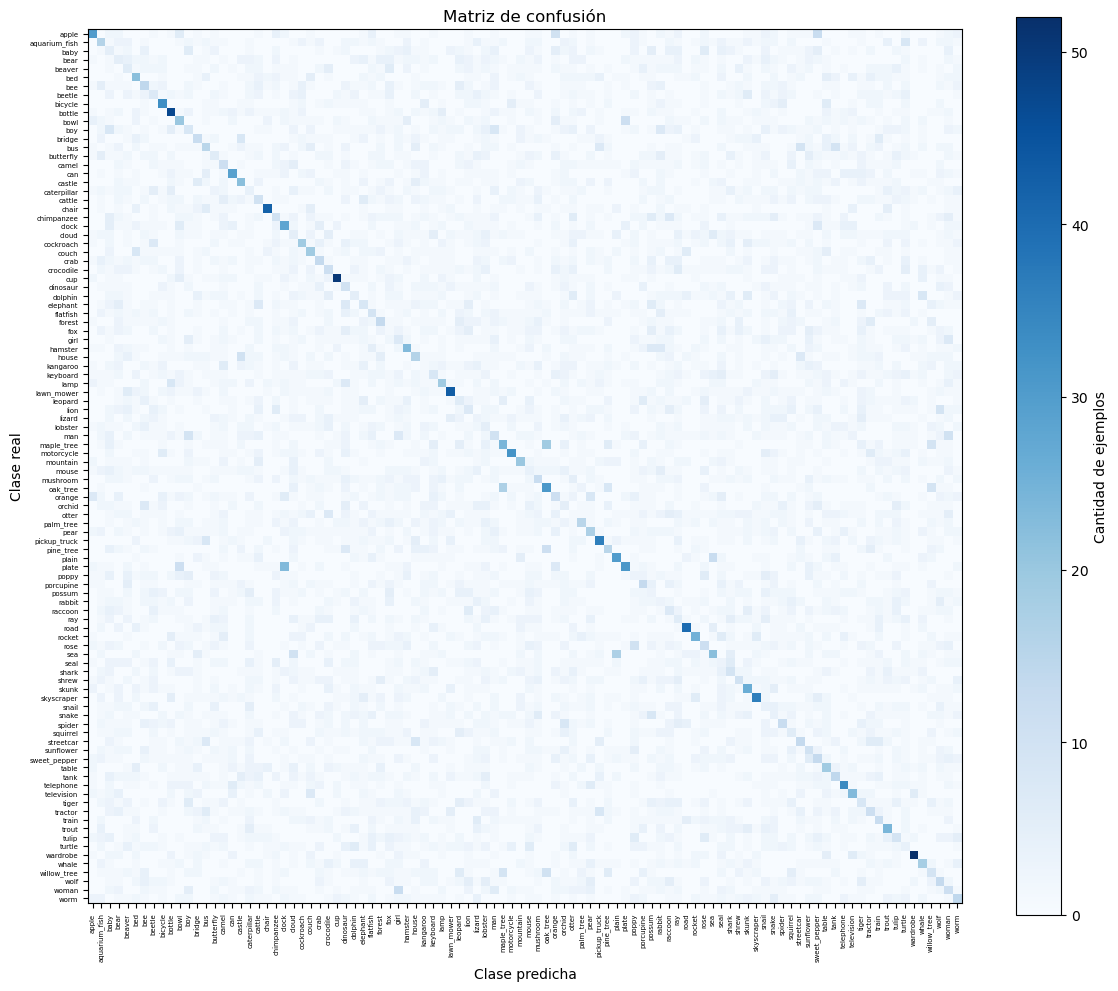

In [15]:
# Esta celda construye la matriz de confusión (cuántas veces se predijo cada clase vs la clase real).
# Sirve para ver qué clases confunde más el modelo entre sí.
matriz_confusion = np.zeros((num_labels, num_labels), dtype=int)
for real, predicho in zip(y_test, pred_test):
    matriz_confusion[real, predicho] += 1

pyplot.figure(figsize=(12, 10))
pyplot.imshow(matriz_confusion, cmap='Blues')
pyplot.colorbar(label='Cantidad de ejemplos')
pyplot.xlabel('Clase predicha')
pyplot.ylabel('Clase real')
pyplot.title('Matriz de confusión')
pyplot.xticks(range(num_labels), clases, rotation=90, fontsize=5)
pyplot.yticks(range(num_labels), clases, fontsize=5)
pyplot.tight_layout()
pyplot.show()

In [16]:
# Esta celda identifica los pares de clases más confundidos entre sí (excluyendo la diagonal, que son los aciertos).
# Sirve para detectar qué clases son visualmente parecidas para el modelo.
pares = []
for i in range(num_labels):
    for j in range(num_labels):
        if i != j and matriz_confusion[i, j] > 0:
            pares.append((matriz_confusion[i, j], clases[i], clases[j]))

pares.sort(reverse=True)
print("Clase real -> Clase predicha : cantidad de confusiones")
for cantidad, real, predicho in pares[:15]:
    print(f"{real:20s} -> {predicho:20s} : {cantidad}")

Clase real -> Clase predicha : cantidad de confusiones
plate                -> clock                : 23
maple_tree           -> oak_tree             : 19
sea                  -> plain                : 17
oak_tree             -> maple_tree           : 17
woman                -> girl                 : 12
plain                -> sea                  : 12
apple                -> sweet_pepper         : 12
plate                -> bowl                 : 11
pine_tree            -> oak_tree             : 11
bowl                 -> plate                : 11
willow_tree          -> oak_tree             : 10
sea                  -> cloud                : 10
rose                 -> poppy                : 10
man                  -> woman                : 10
house                -> castle               : 10


## 12. Inspección visual de predicciones

Por último, se muestra una cuadrícula de imágenes del conjunto de prueba junto con su predicción y su valor real, coloreando en verde los aciertos y en rojo los errores, para inspeccionar cualitativamente el desempeño del modelo.

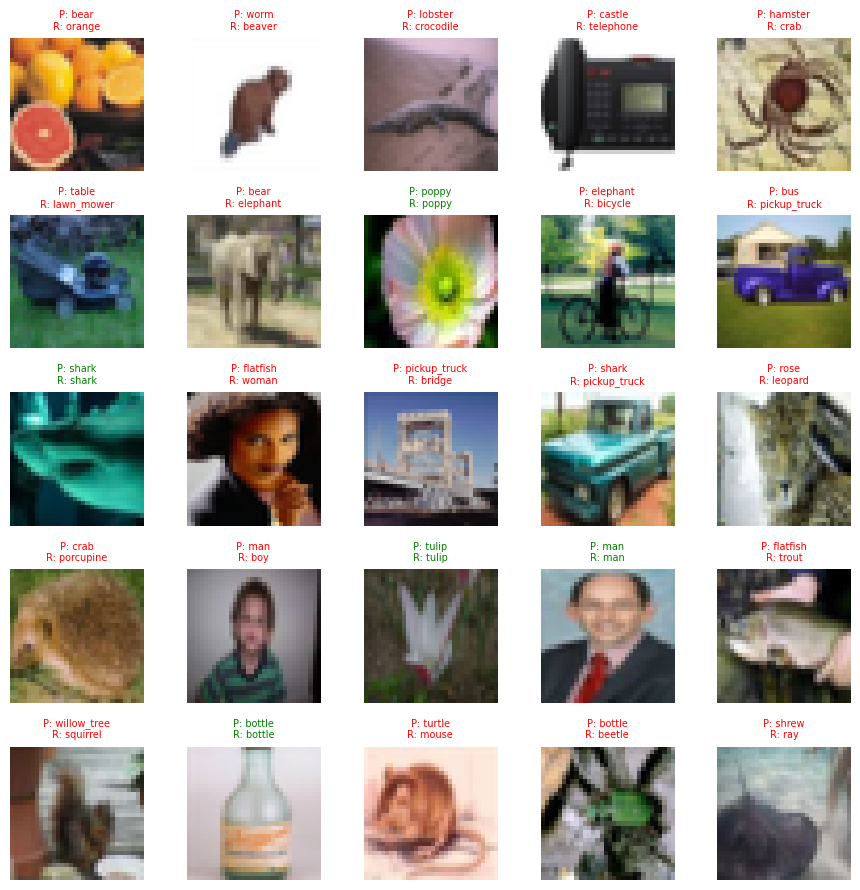

In [17]:
# Esta celda muestra una cuadrícula de imágenes de prueba con su predicción y valor real.
# Sirve para inspeccionar visualmente los aciertos y errores del modelo.
n_muestra = min(25, X_test.shape[0])
rand_indices_test = np.random.choice(X_test.shape[0], n_muestra, replace=False)

filas_grid = int(np.ceil(np.sqrt(n_muestra)))
fig, axes = pyplot.subplots(filas_grid, filas_grid, figsize=(9, 9))
for ax, idx in zip(np.array(axes).ravel(), rand_indices_test):
    imagen = X_test[idx].reshape(32, 32, 3).astype(np.uint8)
    correcto = pred_test[idx] == y_test[idx]
    color = 'green' if correcto else 'red'
    ax.imshow(imagen)
    ax.set_title(f'P: {clases[pred_test[idx]]}\nR: {clases[y_test[idx]]}', fontsize=7, color=color)
    ax.axis('off')
pyplot.tight_layout()
pyplot.show()

## Conclusión

- **Extracción de características HOG**: Al transformar los 3072 píxeles crudos a 1568 descriptores HOG, el modelo captura patrones de bordes y orientación de formas locales, reduciendo drásticamente el ruido causado por fondos diversos e iluminación en CIFAR-100.
- **Efecto de Lambda bajo (`lambda_ = 0.1`)**: Al contar con representaciones de HOG más discriminativas, una menor penalización de regularización permite ajustar fronteras de decisión más precisas por clase.
- **Evaluación en las 100 clases**: Se observó una mejora significativa en la precisión general respecto a los píxeles crudos, permitiendo analizar el comportamiento individual en todas y cada una de las 100 clases del dataset.